# Donchian Breakout (Custom Indicator Example)

This notebook shows how to write a **custom indicator** by subclassing
`overfitting.indicators.Indicator`, and use it in a strategy.

We implement a **Donchian channel** and build a classic
Turtle-style breakout strategy on top of it.

## Strategy Logic
- **Entry**: today's close breaks **above** the prior 20-period high.
- **Exit**: today's close drops **below** the prior 20-period low.

## 1. Writing a custom indicator

In [ ]:
import pandas as pd
from overfitting import Strategy
from overfitting.indicators import Indicator


class Donchian(Indicator):
    def __init__(self, high: pd.Series, low: pd.Series, window: int = 20):
        self.high = high
        self.low = low
        self.window = window
        super().__init__()

    def compute(self):
        # shift(2) so the channel at bar i excludes bar i-1; lets the
        # strategy compare close[i-1] vs upper[i] meaningfully.
        upper = self.high.rolling(self.window).max().shift(2)
        lower = self.low.rolling(self.window).min().shift(2)
        self._values = pd.DataFrame({
            "upper": upper,
            "lower": lower,
            "mid":   (upper + lower) / 2,
        })

## 2. Load the data

In [2]:
def load_data():
    df = pd.read_csv('./data/BTCUSDT.csv')
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)

    start_time = pd.to_datetime('2023-01-01 00:00:00')
    df = df.loc[start_time:]
    return df


price_df = load_data()
backtest_data = {"BTC": price_df}
price_df.head()

,open,high,low,close,volume,close_time
timestamp,,,,,,
2023-01-01 00:00:00,16537.5,16540.9,16504.0,16527.0,5381.399,1672534799999
2023-01-01 01:00:00,16527.1,16554.3,16524.1,16550.4,3210.826,1672538399999
2023-01-01 02:00:00,16550.5,16557.1,16534.8,16542.4,2399.668,1672541999999
2023-01-01 03:00:00,16542.5,16542.5,16515.0,16529.3,3214.480,1672545599999
2023-01-01 04:00:00,16529.2,16530.4,16508.8,16517.8,3150.954,1672549199999


## 3. The breakout strategy

There are two equivalent ways to attach a custom indicator inside `init()`:

**Via the helper** — `self.indicator()` introspects `Donchian.__init__`,
sees the `high` and `low` params, and auto-binds the matching series for
the symbol. Anything left over (`window=...`) is forwarded as a kwarg:
```python
self.dc = self.indicator(Donchian, self.asset, window=20)
```

**Or directly**, using the OHLCV series accessors on `Strategy`:
```python
self.dc = Donchian(self.high(self.asset), self.low(self.asset), window=20)
```

Both produce the same indicator. Use whichever you prefer.

In [ ]:
class BreakoutStrategy(Strategy):
    def init(self):
        self.asset = 'BTC'
        self.window = 20
        self.set_leverage(self.asset, 1)

        # self.indicator() auto-binds high/low from the symbol.
        self.dc = self.indicator(Donchian, self.asset, window=self.window)

    def next(self, i):
        if i < 2:
            return

        upper = self.dc.upper[i]
        lower = self.dc.lower[i]
        if pd.isna(upper) or pd.isna(lower):
            return

        # Use close[i-1], not close[i]: close[i] hasn't happened yet at
        # the start of bar i — reading it would be look-ahead bias.
        prev_close = self.close(self.asset, i - 1)
        position = self.get_position(self.asset)

        if prev_close > upper and position.qty == 0:
            open_price = self.open(self.asset, i)
            lot_size = self.get_balance() // open_price
            if lot_size > 0:
                self.market_order(self.asset, lot_size)

        elif prev_close < lower and position.qty > 0:
            self.market_order(self.asset, -position.qty)

## 4. Run and plot

Performance Summary
Number of Years               1.66000000
Start Date           2023-01-01 00:00:00
End Date             2024-08-29 00:00:00
Initial Balance         100,000.00000000
Final Balance           142,692.35872000
CAGR                          0.23878840
Cumulative Return             1.42692359
Sharpe Ratio                  0.71847651
Sortino Ratio                 1.90095072
Max Drawdown                 -0.29690235
Daily Value At Risk          -0.04109673
Skew                          0.82865884
Kurtosis                      2.71217903
Total Trades                150.00000000
Winning Trades               48.00000000
Losing Trades               102.00000000
Win Rate (%)                 32.00000000
Gross Profit            255,369.29752000
Gross Loss             -212,676.93880000
Net Profit               42,692.35872000
Avg Return (%)                0.20101463
Avg Profit (%)                4.49986794
Avg Loss (%)                 -1.82197516
  Net drawdown in %  Peak date Valley

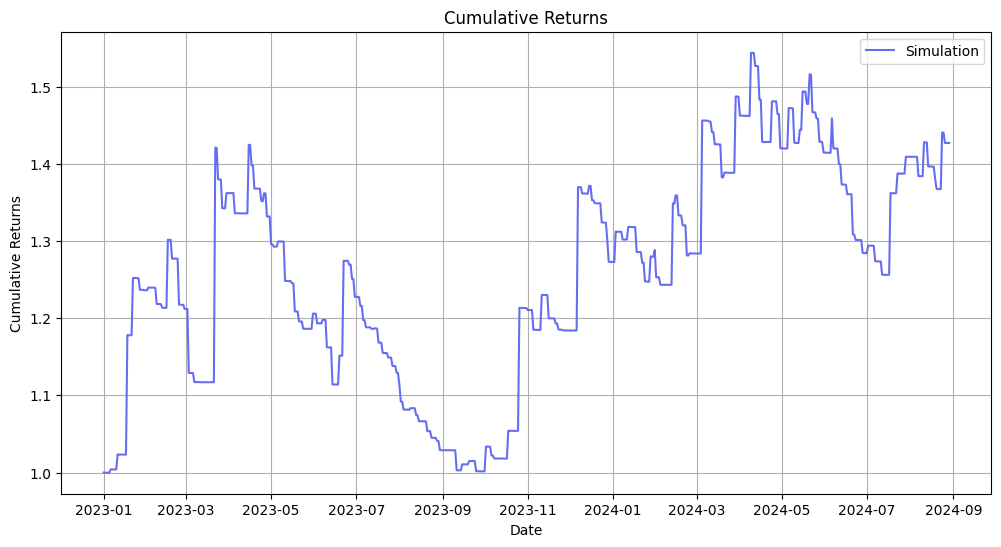

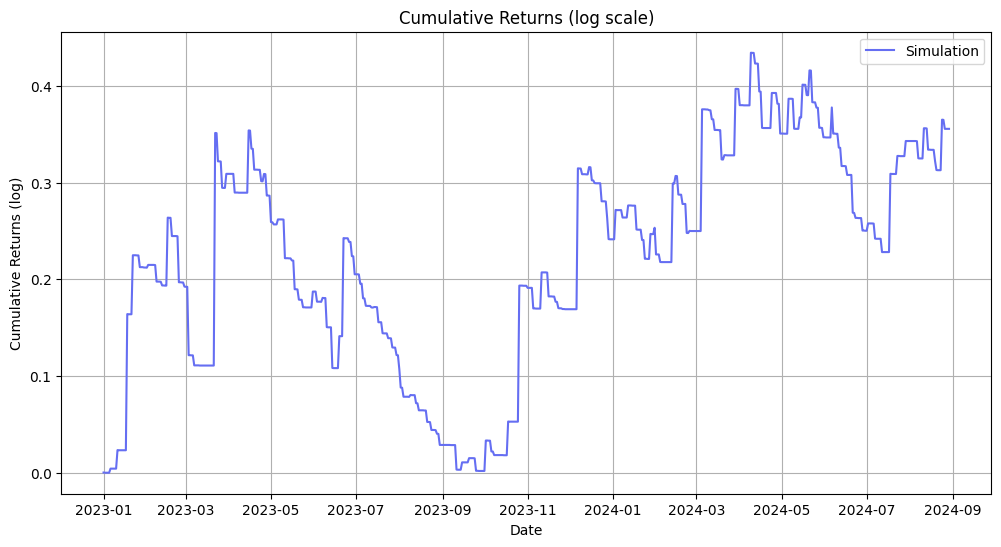

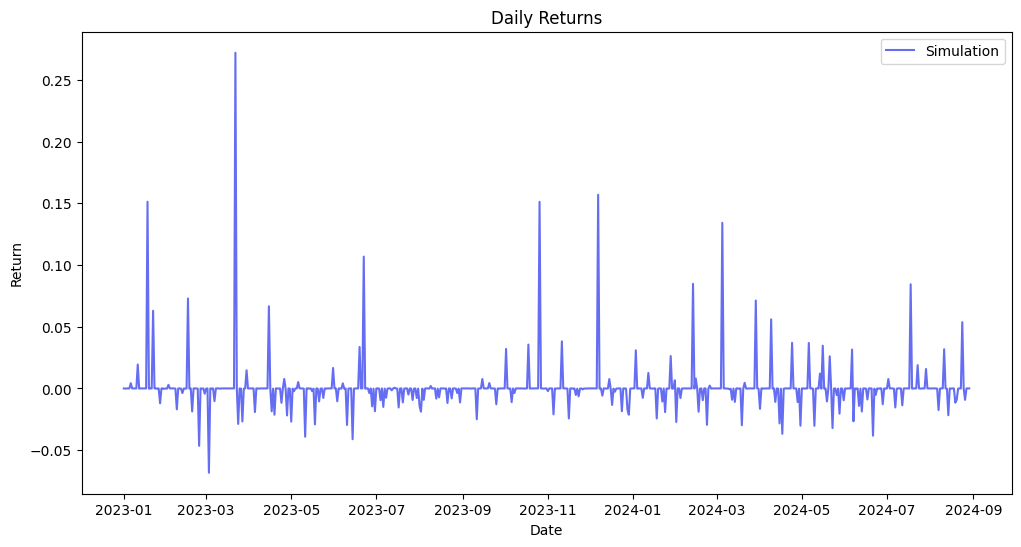

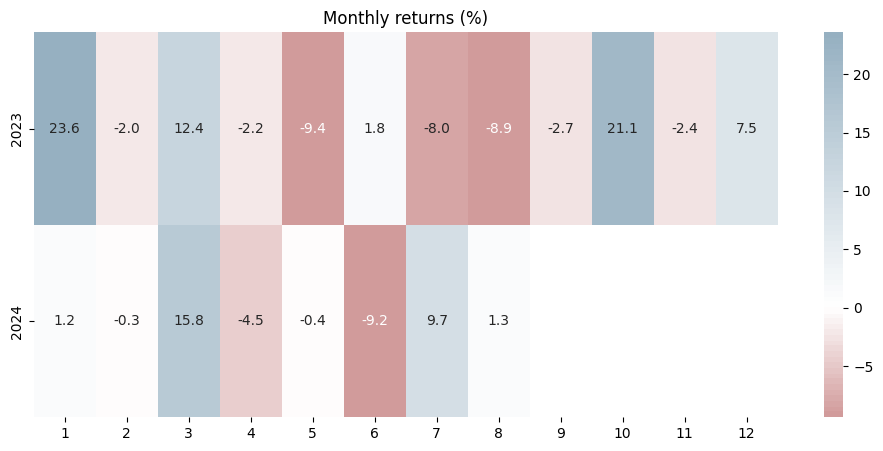

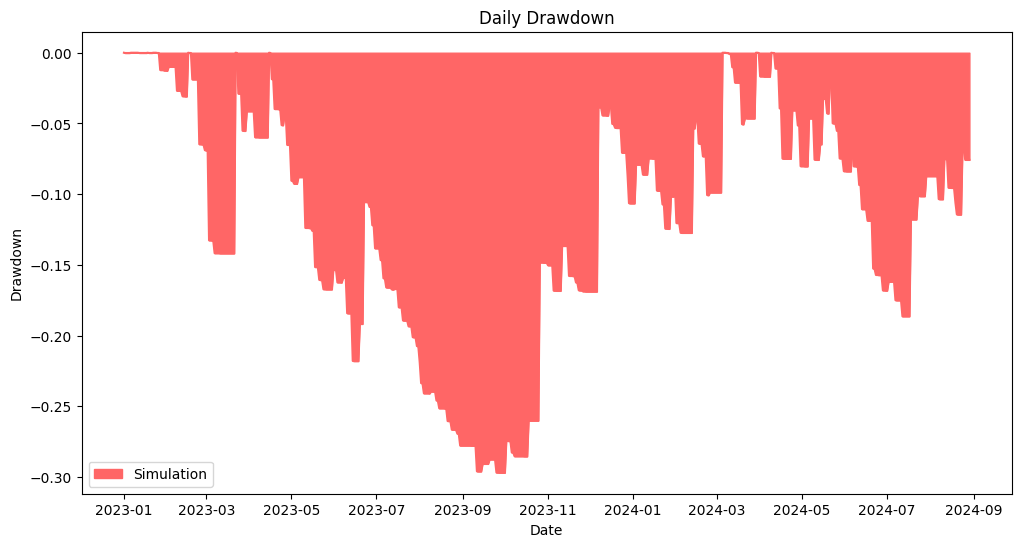

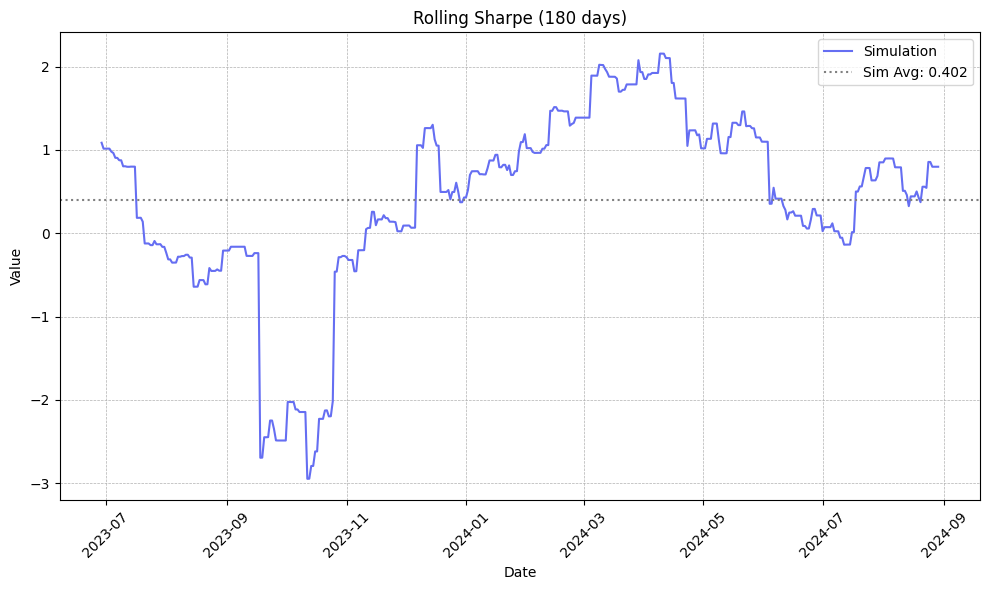

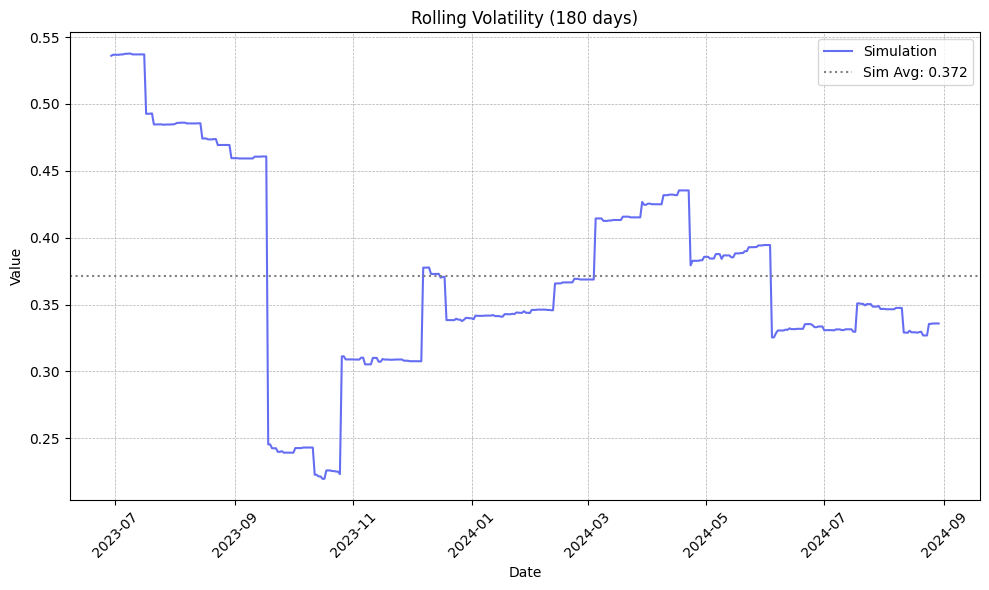

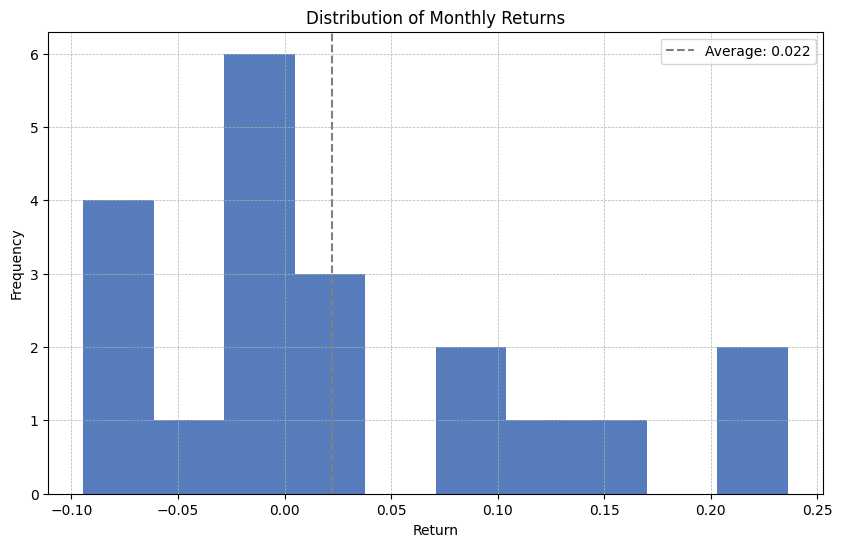

In [4]:
strategy = BreakoutStrategy(data=backtest_data, initial_capital=100_000)
returns = strategy.run()
strategy.plot(returns)

## 5. Inspect trades

In [5]:
strategy.fetch_trades()

,id,created_at,executed_at,symbol,qty,side,price,type,stop_price,is_triggered,is_liquidation_order,theoretical_price,executed_price,commission,pnl,realized_pnl,label
0,5e87535678e740ca,2023-01-02 04:00:00,2023-01-02 04:00:00,BTC,6.0,LONG,None,MARKET,None,False,False,16654.7,16654.7,19.98564,0.0,-19.98564,None
1,4fb1dc7e3d8e4123,2023-01-06 12:00:00,2023-01-06 12:00:00,BTC,-6.0,SHORT,None,MARKET,None,False,False,16731.5,16731.5,20.07780,460.8,440.72220,None
2,fc77520712e549b8,2023-01-06 20:00:00,2023-01-06 20:00:00,BTC,5.0,LONG,None,MARKET,None,False,False,16932.7,16932.7,16.93270,0.0,-16.93270,None
3,1d28dc2adec34f2f,2023-01-11 16:00:00,2023-01-11 16:00:00,BTC,-5.0,SHORT,None,MARKET,None,False,False,17325.2,17325.2,17.32520,1962.5,1945.17480,None
4,0ae0b61831524c6f,2023-01-12 00:00:00,2023-01-12 00:00:00,BTC,5.0,LONG,None,MARKET,None,False,False,17935.6,17935.6,17.93560,0.0,-17.93560,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,34ea6382259e4a53,2024-08-20 16:00:00,2024-08-20 16:00:00,BTC,-2.0,SHORT,None,MARKET,None,False,False,58783.7,58783.7,23.51348,-1229.4,-1252.91348,None
296,46f25921a3c5423b,2024-08-21 14:00:00,2024-08-21 14:00:00,BTC,2.0,LONG,None,MARKET,None,False,False,59904.0,59904.0,23.96160,0.0,-23.96160,None
297,77e5f55ab730467b,2024-08-24 22:00:00,2024-08-24 22:00:00,BTC,-2.0,SHORT,None,MARKET,None,False,False,63584.1,63584.1,25.43364,7360.2,7334.76636,None
298,4d26ff5f7df246b5,2024-08-25 22:00:00,2024-08-25 22:00:00,BTC,2.0,LONG,None,MARKET,None,False,False,64359.0,64359.0,25.74360,0.0,-25.74360,None
